In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Add species name
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


In [3]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(150, 6)


In [4]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [5]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [7]:
print("\nClass Distribution:")
print(df["species"].value_counts())


Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


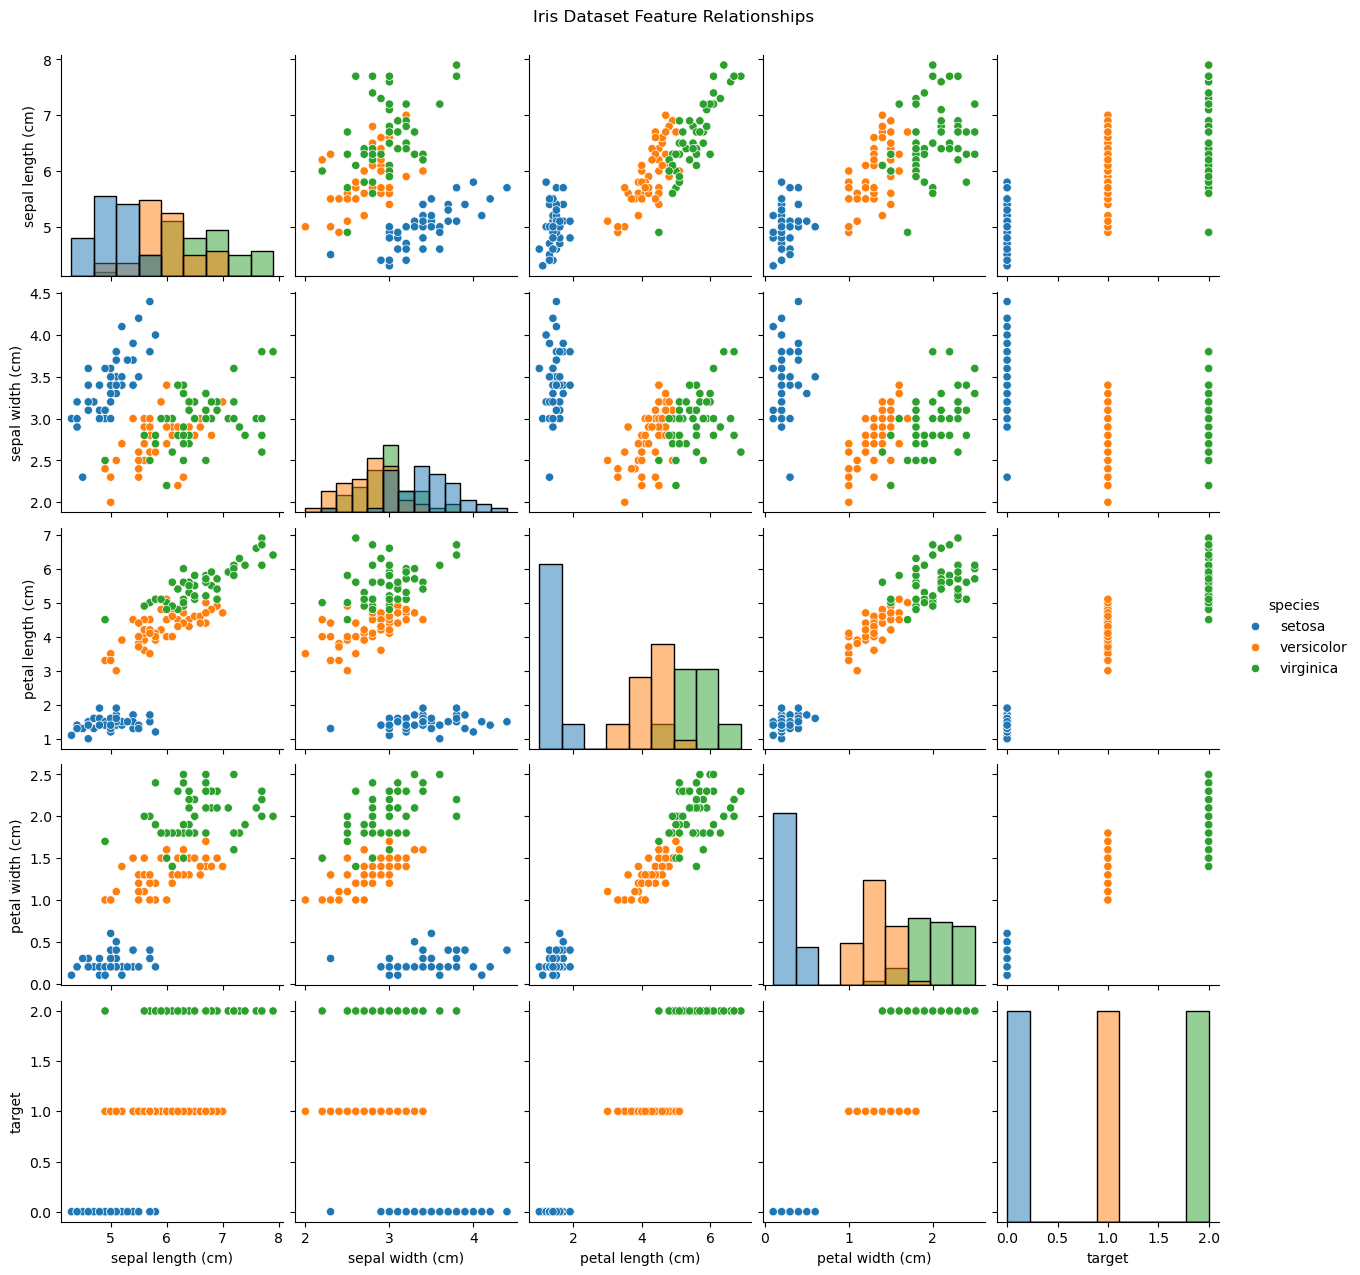

In [8]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Iris Dataset Feature Relationships",
    y=1.02
)

plt.show()

In [9]:
X = df[iris.feature_names]
y = df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [12]:
logistic_model = LogisticRegression(
    max_iter=200
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# Predictions
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [13]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("\n====================================")
print("LOGISTIC REGRESSION")
print("====================================")

print(
    "Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=iris.target_names
    )
)


LOGISTIC REGRESSION
Accuracy: 93.33 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



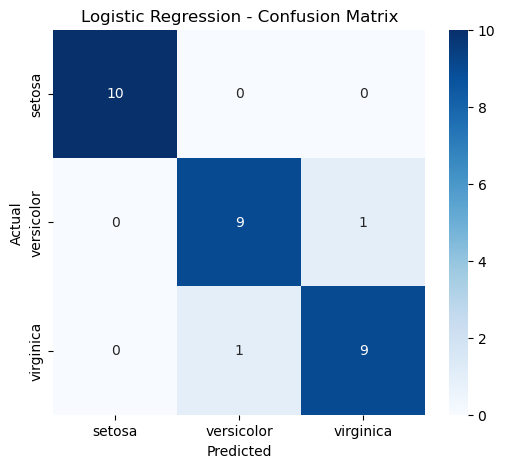

In [14]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

# Predictions
rf_predictions = random_forest.predict(
    X_test
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [16]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\n====================================")
print("RANDOM FOREST")
print("====================================")

print(
    "Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=iris.target_names
    )
)


RANDOM FOREST
Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



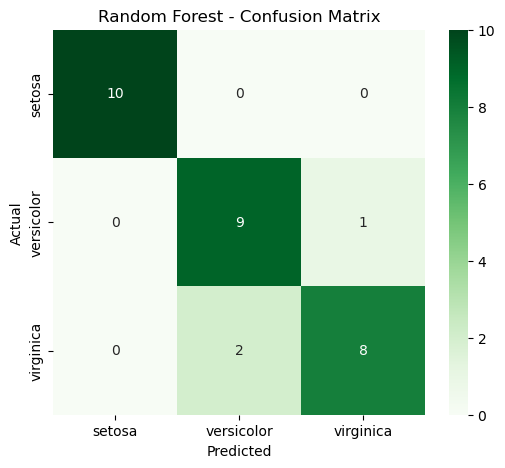

In [17]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

print("\n====================================")
print("MODEL COMPARISON")
print("====================================")

print(model_comparison)


MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.933333
1        Random Forest  0.900000


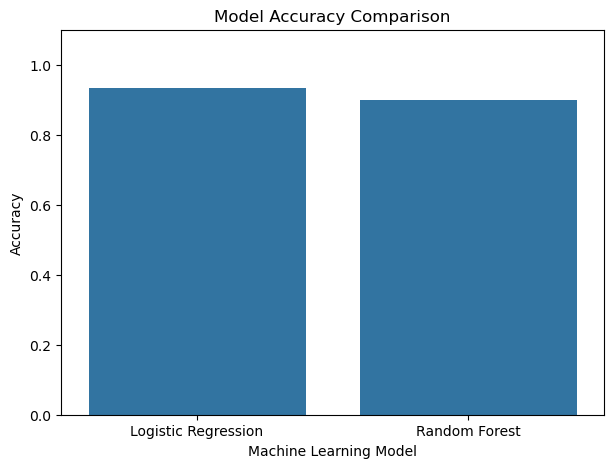

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Model")

plt.show()

In [20]:
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
             Feature  Importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


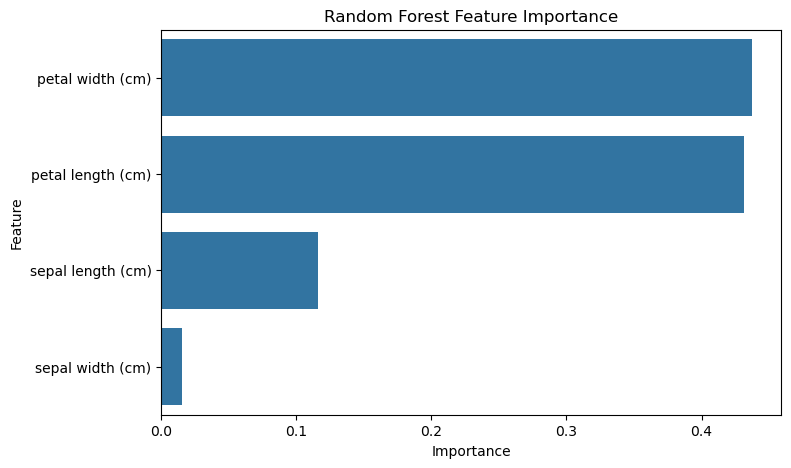

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [22]:
# Example flower:
# Sepal Length = 5.1
# Sepal Width  = 3.5
# Petal Length = 1.4
# Petal Width  = 0.2

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

print("New flower data:")
print(new_flower)

New flower data:
[[5.1 3.5 1.4 0.2]]


In [23]:
# Scale input for Logistic Regression
new_flower_scaled = scaler.transform(
    new_flower
)

# Logistic Regression prediction
logistic_result = logistic_model.predict(
    new_flower_scaled
)

print(
    "Logistic Regression Prediction:",
    iris.target_names[logistic_result[0]]
)

Logistic Regression Prediction: setosa


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
# Random Forest prediction
rf_result = random_forest.predict(
    new_flower
)

print(
    "Random Forest Prediction:",
    iris.target_names[rf_result[0]]
)

Random Forest Prediction: setosa


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [25]:
print("\n====================================")
print("NEW FLOWER PREDICTION")
print("====================================")

print(
    "Logistic Regression Prediction:",
    iris.target_names[logistic_result[0]]
)

print(
    "Random Forest Prediction:",
    iris.target_names[rf_result[0]]
)


NEW FLOWER PREDICTION
Logistic Regression Prediction: setosa
Random Forest Prediction: setosa
